# H1: Evaluating format sensitivity

In [14]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from fsr.corpus.layout import META_NAME, split_dir
from fsr.formats import FORMAT_NAMES
from fsr.h1_results import (
    answer_intervals,
    answer_table,
    available,
    bootstrap_frame,
    load_axis,
    measured_counts,
    pairwise_table,
    per_format_top1,
    score_intervals,
    score_table,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.dpi": 100,
        "grid.linewidth": 0.6,
        "grid.alpha": 0.45,
        "axes.edgecolor": "0.3",
        "axes.linewidth": 0.9,
    }
)

BAR_FILL = sns.color_palette("pastel")[0]
BAR_EDGE = sns.color_palette("muted")[0]
MUTED_FILL = "0.88"
MUTED_EDGE = "0.6"
RULE = "0.35"
BAND = "0.86"
ERROR = "0.45"
HEATMAP = "BuPu"
D_THRESHOLDS = ((0.2, "small"), (0.5, "medium"), (0.8, "large"))

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
DATA_ROOT = ROOT / "data" / "nq"
FIG_DIR = ROOT / "notebooks" / "h1" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODE = "with_body"
SPLIT = "test"
CHECK = "nq_val"
DESCRIPTIVE = "all"
RECORD_SETS = (SPLIT, CHECK, DESCRIPTIVE)
LABEL = {SPLIT: "test", CHECK: "nq_val", DESCRIPTIVE: "pooled"}


def save(fig, name):
    """Write the figure as a vector PDF for the thesis and a PNG to read."""
    fig.tight_layout()
    for suffix in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{suffix}", bbox_inches="tight")


cross = {
    s: load_axis(DATA_ROOT, s, "cross", MODE)
    for s in available(DATA_ROOT, "cross", MODE)
}
within = {
    s: load_axis(DATA_ROOT, s, "within", MODE)
    for s in available(DATA_ROOT, "within", MODE)
}
print("score axis: ", ", ".join(LABEL[s] for s in cross))
print("answer axis:", ", ".join(LABEL[s] for s in within))

meta = json.loads((split_dir(DATA_ROOT) / META_NAME).read_text())
counts = measured_counts(DATA_ROOT, MODE)
pooled = sum(meta[f"n_records_{s}"] for s in ("train", "dev", "test"))
groups = {
    "nq_train": [
        ("train", meta["n_records_train"], None),
        ("dev", meta["n_records_dev"], None),
        ("test", meta["n_records_test"], SPLIT),
        ("pooled", pooled, DESCRIPTIVE),
    ],
    "nq_validation": [("nq_val", meta["nq_val_n_records"], CHECK)],
}
print()
for group, rows in groups.items():
    print(group)
    for name, size, record_set in rows:
        used = counts.get(record_set, {})
        measured = (
            f"{used['records']:>6,} score axis, {used['queries']:>6,} answer axis"
            if used
            else ""
        )
        print(f"  {name:<8}{size:>7,}{measured}")

score axis:  test, nq_val, pooled
answer axis: test, nq_val, pooled

nq_train
  train     6,580
  dev         787
  test        821   770 score axis,    767 answer axis
  pooled    8,188 7,659 score axis,  7,642 answer axis
nq_validation
  nq_val      171   159 score axis,    158 answer axis


## Score axis


In [15]:
scores = score_table(cross[SPLIT])
scores.round(3)

,max_abs_d,max_d_pair,mean_abs_d,max_flip_pct,min_rho
model,,,,,
MiniLM-L6,0.903,yaml - toml,0.496,12.319,0.910
MiniLM-L12,0.938,yaml - toml,0.433,9.951,0.946
bge-base,0.383,json - inline_kv,0.191,13.215,0.904
bge-v2-m3,0.452,yaml - inline_kv,0.279,8.700,0.959
mxbai-v1,0.650,yaml - toml,0.404,5.742,0.980
jina-v2,0.899,yaml - inline_kv,0.480,7.769,0.963


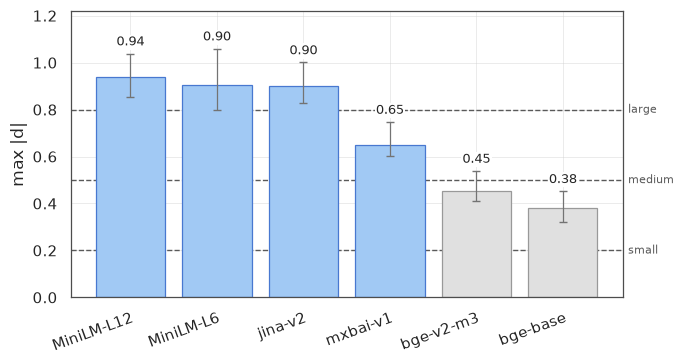

In [16]:
intervals = score_intervals(cross[SPLIT]).loc[scores.index]
order = intervals.sort_values("max_abs_d", ascending=False)
err = [order["max_abs_d"] - order["low"], order["high"] - order["max_abs_d"]]
above = order["max_abs_d"] > 0.5

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.bar(
    order.index,
    order["max_abs_d"],
    zorder=2,
    color=[BAR_FILL if a else MUTED_FILL for a in above],
    edgecolor=[BAR_EDGE if a else MUTED_EDGE for a in above],
    linewidth=0.9,
    yerr=err,
    capsize=3,
    error_kw={"lw": 0.9, "ecolor": ERROR, "zorder": 3},
)
for x, (value, high) in enumerate(zip(order["max_abs_d"], order["high"], strict=True)):
    ax.text(
        x,
        high + 0.035,
        f"{value:.2f}",
        ha="center",
        fontsize=9,
        bbox={"facecolor": "white", "edgecolor": "none", "pad": 1},
    )

for level, name in D_THRESHOLDS:
    ax.axhline(level, color=RULE, ls="--", lw=1, zorder=1)
    ax.text(
        1.01,
        level,
        name,
        color=RULE,
        fontsize=8,
        va="center",
        transform=ax.get_yaxis_transform(),
    )

ax.set_ylabel("max |d|")
ax.set_xlabel("")
ax.set_ylim(0, order["high"].max() * 1.15)
plt.setp(ax.get_xticklabels(), rotation=20, ha="right", rotation_mode="anchor")
save(fig, "score_axis_max_abs_d")

Four of the six exceed the medium threshold. The two BGE-family models
fall below it.


### Format pairs


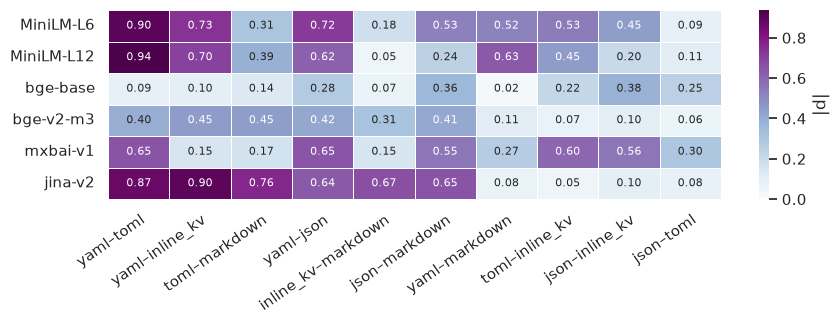

In [17]:
pairs = pairwise_table(cross[SPLIT])
pairs["pair"] = pairs["left"] + "\u2013" + pairs["right"]
grid = pairs.pivot(index="model", columns="pair", values="abs_d")
grid = grid.loc[scores.index]
grid = grid[grid.max().sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(9, 3.4))
sns.heatmap(
    grid,
    annot=True,
    fmt=".2f",
    cmap=HEATMAP,
    vmin=0,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"fontsize": 8},
    cbar_kws={"label": "|d|"},
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("")
plt.setp(ax.get_xticklabels(), rotation=35, ha="right", rotation_mode="anchor")
save(fig, "score_axis_pairs")

## Answer axis


In [18]:
answers = answer_table(within[SPLIT])
answers.round(2)

,inconsistency_pct,answerable_pct,top1_all_formats_pct,top1_format_dependent_pct,top1_never_pct,max_flip_pct,min_tau,delta_over_s
model,,,,,,,,
MiniLM-L6,14.39,87.87,75.23,12.65,12.13,8.70,0.83,0.11
MiniLM-L12,11.94,89.57,78.88,10.69,10.43,10.14,0.80,0.11
bge-base,17.67,90.74,74.71,16.04,9.26,12.56,0.75,0.18
bge-v2-m3,4.66,95.18,90.74,4.43,4.82,10.33,0.79,0.10
mxbai-v1,3.75,90.35,86.96,3.39,9.65,4.74,0.91,0.05
jina-v2,4.90,93.22,88.66,4.56,6.78,5.13,0.90,0.06


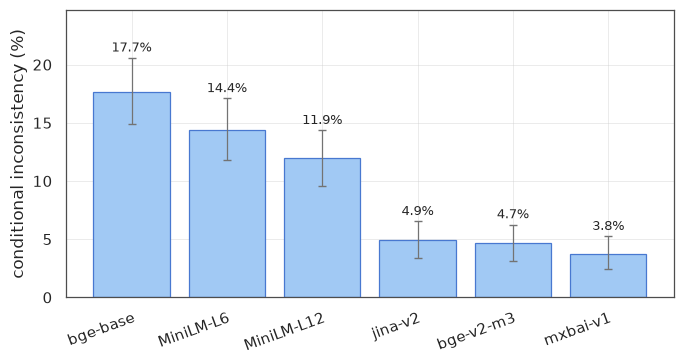

In [19]:
intervals = answer_intervals(within[SPLIT]).loc[answers.index]
order = intervals.sort_values("inconsistency_pct", ascending=False)
point = order["inconsistency_pct"]
err = [point - order["low"], order["high"] - point]

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.bar(
    order.index,
    point,
    zorder=2,
    color=BAR_FILL,
    edgecolor=BAR_EDGE,
    linewidth=0.9,
    yerr=err,
    capsize=3,
    error_kw={"lw": 0.9, "ecolor": ERROR, "zorder": 3},
)
for x, (value, high) in enumerate(zip(point, order["high"], strict=True)):
    ax.text(x, high + 0.55, f"{value:.1f}%", ha="center", fontsize=9)
ax.set_ylabel("conditional inconsistency (%)")
ax.set_xlabel("")
ax.set_ylim(0, order["high"].max() * 1.2)
plt.setp(ax.get_xticklabels(), rotation=20, ha="right", rotation_mode="anchor")
save(fig, "answer_axis_inconsistency")

Every model loses answerable queries to serialisation alone and every interval excludes zero. The three most inconsistent models exceed the other three on non-overlapping intervals.


In [20]:
bootstrap_frame(within[SPLIT])[
    [
        "format_dependent_pct",
        "format_dependent_lo",
        "format_dependent_hi",
        "flip_rate_pct",
        "worst_pair",
    ]
].round(2)

,format_dependent_pct,format_dependent_lo,format_dependent_hi,flip_rate_pct,worst_pair
model,,,,,
MiniLM-L6,12.65,10.30,14.99,8.70,json vs inline_kv
MiniLM-L12,10.69,8.60,12.91,10.14,json vs inline_kv
bge-base,16.04,13.43,18.64,12.56,yaml vs toml
bge-v2-m3,4.43,3.00,6.00,10.33,yaml vs json
mxbai-v1,3.39,2.22,4.69,4.74,yaml vs json
jina-v2,4.56,3.13,6.13,5.13,json vs inline_kv


### Gold at rank 1, by format


In [21]:
per_format_top1(within[SPLIT])[[*FORMAT_NAMES, "spread_pp"]].round(1)

,yaml,json,toml,inline_kv,markdown,spread_pp
model,,,,,,
MiniLM-L6,83.4,80.6,81.0,83.4,80.7,2.9
MiniLM-L12,85.7,82.9,85.0,85.8,83.4,2.9
bge-base,86.2,83.2,82.5,85.0,84.0,3.7
bge-v2-m3,93.2,93.2,93.5,94.0,93.0,1.0
mxbai-v1,88.7,88.7,88.9,88.5,88.0,0.9
jina-v2,90.9,90.4,90.5,90.7,91.5,1.2


## Both axes


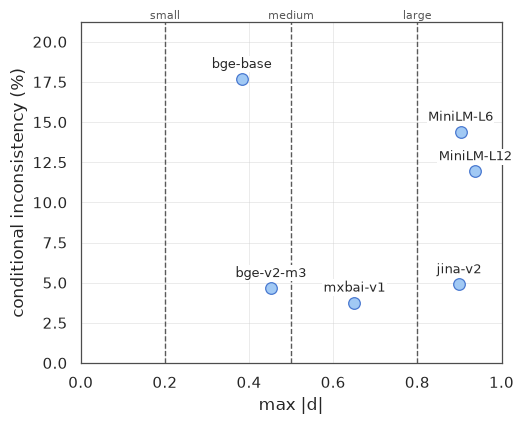

In [22]:
axes = scores[["max_abs_d"]].join(answers[["inconsistency_pct"]])
fig, ax = plt.subplots(figsize=(5.4, 4.4))
ax.scatter(
    axes["max_abs_d"],
    axes["inconsistency_pct"],
    s=70,
    color=BAR_FILL,
    edgecolor=BAR_EDGE,
    linewidth=0.9,
    zorder=3,
)
for label, row in axes.iterrows():
    ax.annotate(
        label,
        (row["max_abs_d"], row["inconsistency_pct"]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9,
        bbox={"facecolor": "white", "edgecolor": "none", "pad": 1},
    )
for level, name in D_THRESHOLDS:
    ax.axvline(level, color=RULE, ls="--", lw=1, zorder=1)
    ax.text(
        level,
        1.01,
        name,
        color=RULE,
        fontsize=8,
        ha="center",
        transform=ax.get_xaxis_transform(),
    )
ax.set_xlabel("max |d|")
ax.set_ylabel("conditional inconsistency (%)")
ax.set_xlim(0, 1.0)
ax.set_ylim(0, axes["inconsistency_pct"].max() * 1.2)
save(fig, "both_axes")

The answer axis does not track the score-axis ordering. The two are
therefore near-independent across the six models and capture distinct
failure modes.


## Robustness checks

In [23]:
import pandas as pd

present = [s for s in RECORD_SETS if s in cross and s in within]
comparison = pd.concat(
    {
        LABEL[s]: score_table(cross[s])[["max_abs_d"]].join(
            answer_table(within[s])[["inconsistency_pct"]]
        )
        for s in present
    },
    axis=1,
)
comparison.round(2)

test                      nq_val                      pooled  \
           max_abs_d inconsistency_pct max_abs_d inconsistency_pct max_abs_d   
model                                                                          
MiniLM-L6       0.90             14.39      1.01             14.93      0.87   
MiniLM-L12      0.94             11.94      1.00             10.22      0.94   
bge-base        0.38             17.67      0.49             20.14      0.36   
bge-v2-m3       0.45              4.66      0.57              7.33      0.48   
mxbai-v1        0.65              3.75      0.64              5.76      0.63   
jina-v2         0.90              4.90      1.06              9.40      0.86   

                              
           inconsistency_pct  
model                         
MiniLM-L6              14.35  
MiniLM-L12             10.68  
bge-base               16.46  
bge-v2-m3               5.01  
mxbai-v1                4.10  
jina-v2                 4.78

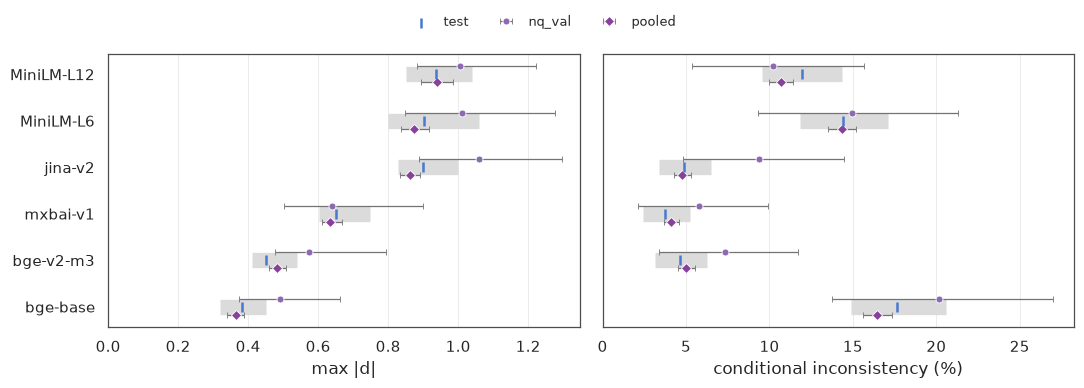

In [24]:
bands = {
    "cross": {s: score_intervals(cross[s]) for s in present},
    "within": {s: answer_intervals(within[s]) for s in present},
}
order = score_table(cross[SPLIT]).sort_values("max_abs_d", ascending=False).index
panels_spec = (
    ("cross", "max_abs_d", "max |d|"),
    ("within", "inconsistency_pct", "conditional inconsistency (%)"),
)
markers = {
    CHECK: ("o", sns.color_palette("BuPu", 7)[4]),
    DESCRIPTIVE: ("D", sns.color_palette("BuPu", 7)[5]),
}
OFFSET = 0.17

fig, panels = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, (axis, column, label) in zip(panels, panels_spec, strict=True):
    frames = bands[axis]
    y = list(range(len(order)))
    base = frames[SPLIT].loc[order]
    ax.hlines(y, base["low"], base["high"], color=BAND, lw=11, zorder=1)
    ax.scatter(
        base[column],
        y,
        s=46,
        marker="|",
        color=BAR_EDGE,
        linewidth=1.8,
        zorder=4,
        label=LABEL[SPLIT],
    )
    for step, (record_set, (marker, colour)) in enumerate(markers.items()):
        if record_set not in frames:
            continue
        row = frames[record_set].loc[order]
        shifted = [value + (step - 0.5) * 2 * OFFSET for value in y]
        ax.errorbar(
            row[column],
            shifted,
            xerr=[row[column] - row["low"], row["high"] - row[column]],
            fmt=marker,
            markersize=5,
            color=colour,
            markeredgecolor="white",
            markeredgewidth=0.6,
            ecolor=ERROR,
            elinewidth=0.9,
            capsize=2,
            zorder=3,
            label=LABEL[record_set],
        )
    ax.set_yticks(y)
    ax.set_yticklabels(order)
    ax.set_xlabel(label)
    ax.set_xlim(0, None)
    ax.grid(axis="y", visible=False)
panels[0].invert_yaxis()
fig.legend(
    *panels[0].get_legend_handles_labels(),
    loc="upper center",
    bbox_to_anchor=(0.5, 1.09),
    ncol=3,
    frameon=False,
    fontsize=9,
)
save(fig, "robustness_checks")
None

The grey band is the 95% interval of the `test` split.

`pooled` is `train`, `dev` and `test` together to describe the measurement at scale.
`nq_val` comes from the NQ validation split, which is a separate set of
articles as an independent check.